# CUFSF Baseline Retrieval Notebook

This notebook builds the first retrieval baseline for the processed CUFSF dataset.

Goal:

```text
query sketch -> rank photo gallery -> evaluate whether the correct photo appears in top-K
```

Baselines included:

1. Random retrieval baseline
2. Pixel cosine similarity baseline
3. Pretrained ResNet18 feature baseline

Expected input folder:

```text
/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/cufsf_224_gray/
  pairs.csv
  sketches/
  photos/
```

## 1. Imports and configuration

In [1]:
from pathlib import Path
import random
import math
import json

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Change this only if your project moved
ROOT = Path("/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data")
DATASET_DIR = ROOT / "processed" / "cufsf_224_gray"
PAIRS_CSV = DATASET_DIR / "pairs.csv"

OUTPUT_DIR = ROOT / "outputs" / "baseline_cufsf"
RETRIEVAL_DIR = OUTPUT_DIR / "retrieval_examples"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RETRIEVAL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Dataset dir:", DATASET_DIR)
print("Pairs CSV exists:", PAIRS_CSV.exists())

/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/sketch2face/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Dataset dir: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/cufsf_224_gray
Pairs CSV exists: True


## 2. Load and audit the paired dataset

The `pairs.csv` file should contain one row per identity:

```text
id, sketch_path, photo_path, ...
```

The important rule is that each sketch has exactly one correct matching photo.

In [2]:
pairs = pd.read_csv(PAIRS_CSV, dtype={"id": str})
pairs["id"] = pairs["id"].str.zfill(5)

pairs["sketch_exists"] = pairs["sketch_path"].apply(lambda p: Path(p).exists())
pairs["photo_exists"] = pairs["photo_path"].apply(lambda p: Path(p).exists())

print("Rows:", len(pairs))
print("Unique IDs:", pairs["id"].nunique())
print("Sketches exist:", pairs["sketch_exists"].sum(), "/", len(pairs))
print("Photos exist:", pairs["photo_exists"].sum(), "/", len(pairs))
print("Duplicate IDs:", pairs["id"].duplicated().sum())

display(pairs.head())

assert len(pairs) > 0, "No pairs loaded."
assert pairs["sketch_exists"].all(), "Some sketch paths are missing."
assert pairs["photo_exists"].all(), "Some photo paths are missing."
assert pairs["id"].is_unique, "IDs should be unique for this baseline."

Rows: 1194
Unique IDs: 1194
Sketches exist: 1194 / 1194
Photos exist: 1194 / 1194
Duplicate IDs: 0


,id,dataset,sketch_path,photo_path,feret_basename,sketch_exists,photo_exists
0,00001,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00001fb010_930831,True,True
1,00002,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00002fa010_930831,True,True
2,00003,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00003fa010_930831,True,True
3,00004,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00004fb010_930831,True,True
4,00005,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00005fa010_930831,True,True


## 3. Visualize random sketch-photo pairs

Before doing ML, always check that the mapping visually makes sense.

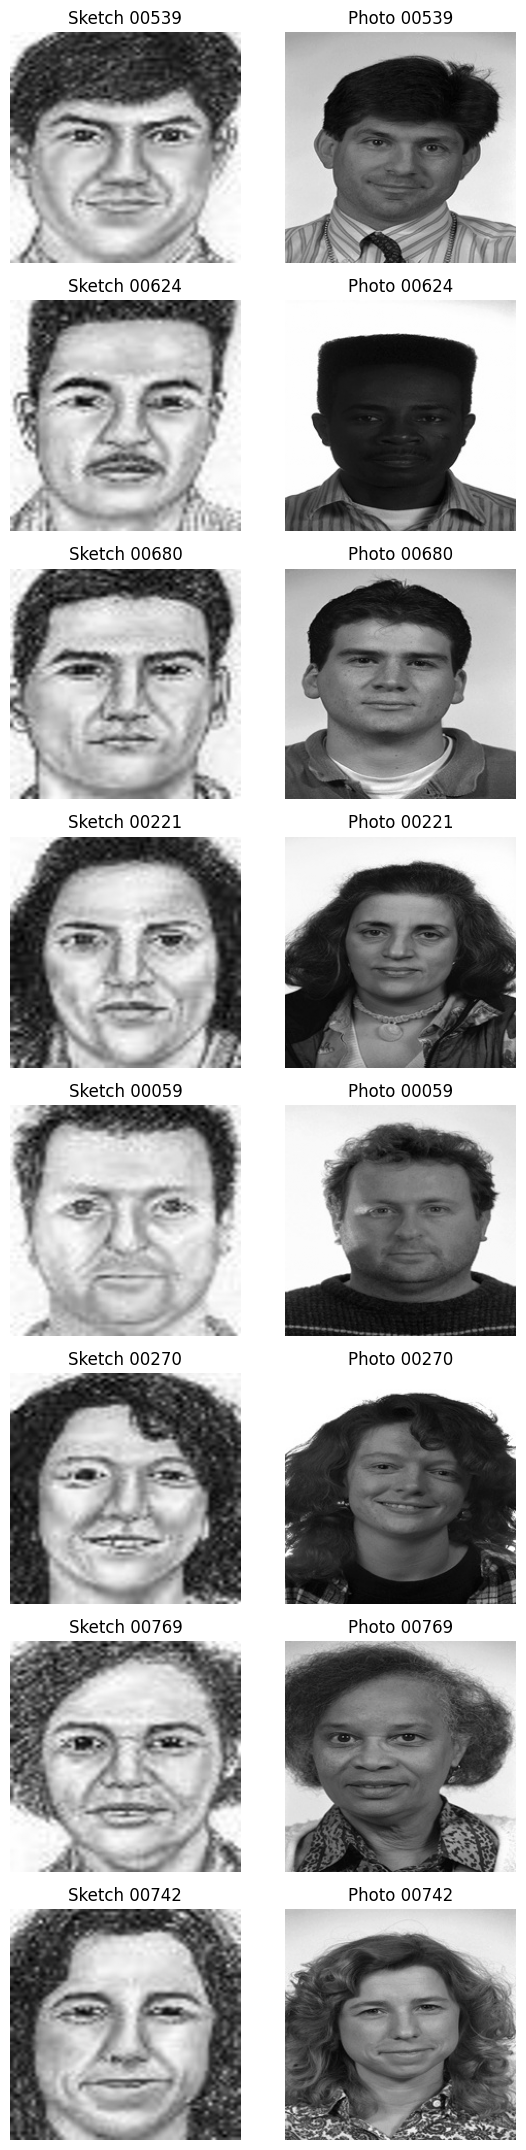

In [3]:
def show_random_pairs(df, n=8, seed=42):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample), 2, figsize=(6, 2.7 * len(sample)))

    if len(sample) == 1:
        axes = np.array([axes])

    for i, row in sample.iterrows():
        sketch = Image.open(row["sketch_path"]).convert("L")
        photo = Image.open(row["photo_path"]).convert("L")

        axes[i, 0].imshow(sketch, cmap="gray")
        axes[i, 0].set_title(f"Sketch {row['id']}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(photo, cmap="gray")
        axes[i, 1].set_title(f"Photo {row['id']}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_random_pairs(pairs, n=8, seed=SEED)

## 4. Train/test split

For the baseline, we evaluate on a held-out test split.

Since CUFSF has one sketch-photo pair per identity, splitting by row is also splitting by identity.

In [4]:
train_df, test_df = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train pairs:", len(train_df))
print("Test pairs:", len(test_df))

train_df.drop(columns=["sketch_exists", "photo_exists"], errors="ignore").to_csv(OUTPUT_DIR / "train_pairs.csv", index=False)
test_df.drop(columns=["sketch_exists", "photo_exists"], errors="ignore").to_csv(OUTPUT_DIR / "test_pairs.csv", index=False)

display(test_df.head())

Train pairs: 955
Test pairs: 239


,id,dataset,sketch_path,photo_path,feret_basename,sketch_exists,photo_exists
0,00539,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00539fa010_940519,True,True
1,00624,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00624fa010_940928,True,True
2,00680,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00680fa010_941121,True,True
3,00221,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00221fa010_940128,True,True
4,00059,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00059fb001d_931230,True,True


## 5. Retrieval metrics

For each sketch query, the system ranks all candidate photos in the gallery.

Metrics:

- **Recall@1**: correct photo is ranked first
- **Recall@5**: correct photo is somewhere in the top 5
- **Recall@10**: correct photo is somewhere in the top 10
- **MRR**: Mean Reciprocal Rank, rewards placing the correct result higher

In [5]:
def evaluate_similarity_matrix(similarity: np.ndarray, query_ids, gallery_ids, ks=(1, 5, 10)):
    """
    similarity shape: [num_queries, num_gallery]
    Higher score means more similar.
    query_ids[i] should match exactly one gallery_ids[j].
    """
    query_ids = list(query_ids)
    gallery_ids = list(gallery_ids)

    gallery_id_to_index = {gid: idx for idx, gid in enumerate(gallery_ids)}

    ranks = []
    for i, qid in enumerate(query_ids):
        if qid not in gallery_id_to_index:
            raise ValueError(f"Query id {qid} not found in gallery.")

        correct_idx = gallery_id_to_index[qid]
        ranked_indices = np.argsort(-similarity[i])  # descending similarity
        rank = int(np.where(ranked_indices == correct_idx)[0][0]) + 1
        ranks.append(rank)

    ranks = np.array(ranks)

    metrics = {}
    for k in ks:
        metrics[f"Recall@{k}"] = float(np.mean(ranks <= k))

    metrics["MRR"] = float(np.mean(1.0 / ranks))
    metrics["MeanRank"] = float(np.mean(ranks))
    metrics["MedianRank"] = float(np.median(ranks))

    return metrics, ranks


def print_metrics(name, metrics):
    print(f"\n{name}")
    print("-" * len(name))
    for k, v in metrics.items():
        if k.startswith("Recall") or k == "MRR":
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v:.2f}")

## 6. Baseline 1 — Random retrieval

This baseline randomly ranks the photo gallery for each sketch.

It tells us the minimum expected performance by chance.

In [6]:
num_queries = len(test_df)
num_gallery = len(test_df)

rng = np.random.default_rng(SEED)

# Random scores create random rankings
random_similarity = rng.random((num_queries, num_gallery))

random_metrics, random_ranks = evaluate_similarity_matrix(
    random_similarity,
    query_ids=test_df["id"],
    gallery_ids=test_df["id"],
)

print_metrics("Random baseline", random_metrics)


Random baseline
---------------
Recall@1: 0.0084
Recall@5: 0.0293
Recall@10: 0.0418
MRR: 0.0274
MeanRank: 123.35
MedianRank: 126.00


## 7. Baseline 2 — Pixel cosine similarity

This is a very simple image baseline.

It flattens each grayscale image into a vector and compares sketches/photos directly with cosine similarity.

This is expected to be weak because sketches and photos are visually different domains.

In [7]:
def load_grayscale_vector(path, size=(224, 224)):
    img = Image.open(path).convert("L").resize(size, Image.BICUBIC)
    arr = np.asarray(img).astype(np.float32) / 255.0
    vec = arr.flatten()
    return vec


def l2_normalize_np(x, axis=1, eps=1e-12):
    return x / (np.linalg.norm(x, axis=axis, keepdims=True) + eps)


sketch_pixels = []
photo_pixels = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Loading pixel vectors"):
    sketch_pixels.append(load_grayscale_vector(row["sketch_path"]))
    photo_pixels.append(load_grayscale_vector(row["photo_path"]))

sketch_pixels = l2_normalize_np(np.stack(sketch_pixels))
photo_pixels = l2_normalize_np(np.stack(photo_pixels))

pixel_similarity = sketch_pixels @ photo_pixels.T

pixel_metrics, pixel_ranks = evaluate_similarity_matrix(
    pixel_similarity,
    query_ids=test_df["id"],
    gallery_ids=test_df["id"],
)

print_metrics("Pixel cosine baseline", pixel_metrics)

Loading pixel vectors: 100%|██████████| 239/239 [00:00<00:00, 913.39it/s] 



Pixel cosine baseline
---------------------
Recall@1: 0.0126
Recall@5: 0.0335
Recall@10: 0.0753
MRR: 0.0399
MeanRank: 105.08
MedianRank: 108.00


## 8. Baseline 3 — Pretrained ResNet18 embeddings

This uses a ResNet18 pretrained on ImageNet as a generic feature extractor.

Important: this model is **not fine-tuned** for sketch-photo matching yet. It is only a baseline.

Later, metric learning should improve over this.

In [8]:
class ImagePathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img


# ImageNet normalization used by pretrained ResNet
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def build_resnet18_feature_extractor(device):
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        print("Loaded pretrained ResNet18 weights.")
    except Exception as e:
        print("Could not load pretrained weights. Falling back to randomly initialized ResNet18.")
        print("Reason:", repr(e))
        model = models.resnet18(weights=None)

    model.fc = nn.Identity()
    model = model.to(device)
    model.eval()
    return model


@torch.no_grad()
def encode_paths(paths, model, transform, batch_size=64, device="cpu"):
    dataset = ImagePathDataset(paths, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    embeddings = []

    for batch in tqdm(loader, desc="Encoding images"):
        batch = batch.to(device)
        emb = model(batch)
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
        embeddings.append(emb.cpu())

    return torch.cat(embeddings, dim=0).numpy()


resnet_model = build_resnet18_feature_extractor(DEVICE)

sketch_embeddings = encode_paths(
    test_df["sketch_path"],
    model=resnet_model,
    transform=resnet_transform,
    batch_size=64,
    device=DEVICE,
)

photo_embeddings = encode_paths(
    test_df["photo_path"],
    model=resnet_model,
    transform=resnet_transform,
    batch_size=64,
    device=DEVICE,
)

print("Sketch embeddings:", sketch_embeddings.shape)
print("Photo embeddings:", photo_embeddings.shape)

resnet_similarity = sketch_embeddings @ photo_embeddings.T

resnet_metrics, resnet_ranks = evaluate_similarity_matrix(
    resnet_similarity,
    query_ids=test_df["id"],
    gallery_ids=test_df["id"],
)

print_metrics("Pretrained ResNet18 baseline", resnet_metrics)

Loaded pretrained ResNet18 weights.


Encoding images: 100%|██████████| 4/4 [00:03<00:00,  1.17it/s]

Sketch embeddings: (239, 512)
Photo embeddings: (239, 512)

Pretrained ResNet18 baseline
----------------------------
Recall@1: 0.0251
Recall@5: 0.0837
Recall@10: 0.1130
MRR: 0.0663
MeanRank: 76.02
MedianRank: 57.00


## 9. Compare baseline results

In [9]:
results = pd.DataFrame([
    {"method": "Random", **random_metrics},
    {"method": "Pixel cosine", **pixel_metrics},
    {"method": "Pretrained ResNet18", **resnet_metrics},
])

display(results)

results.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "baseline_results.csv")

,method,Recall@1,Recall@5,Recall@10,MRR,MeanRank,MedianRank
0,Random,0.008368,0.029289,0.041841,0.027413,123.347280,126.0
1,Pixel cosine,0.012552,0.033473,0.075314,0.039910,105.075314,108.0
2,Pretrained ResNet18,0.025105,0.083682,0.112971,0.066251,76.020921,57.0


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/baseline_cufsf/baseline_results.csv


## 10. Visualize top-K retrieval examples

Each row shows:

```text
query sketch | correct photo | top-5 retrieved photos
```

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/baseline_cufsf/retrieval_examples/random_top5_examples.png


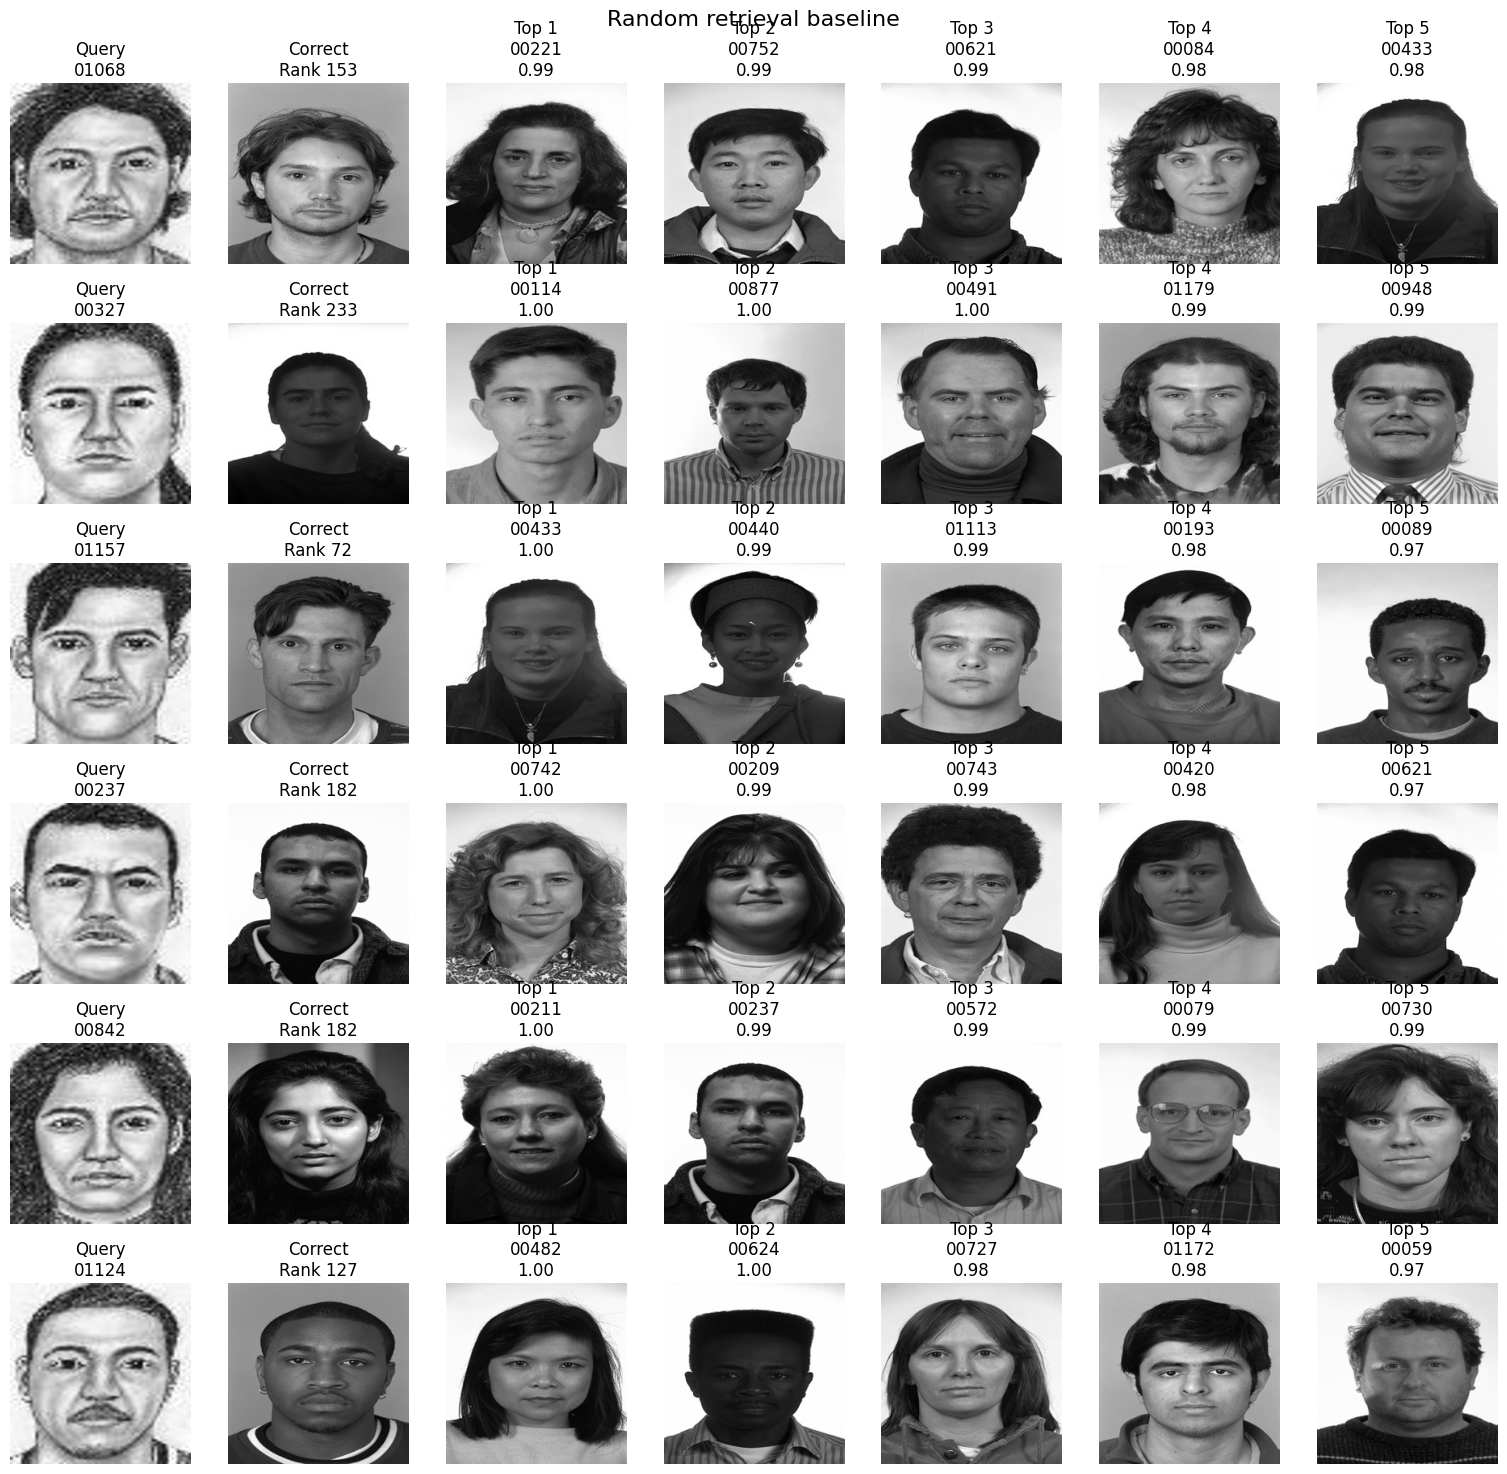

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/baseline_cufsf/retrieval_examples/pixel_top5_examples.png


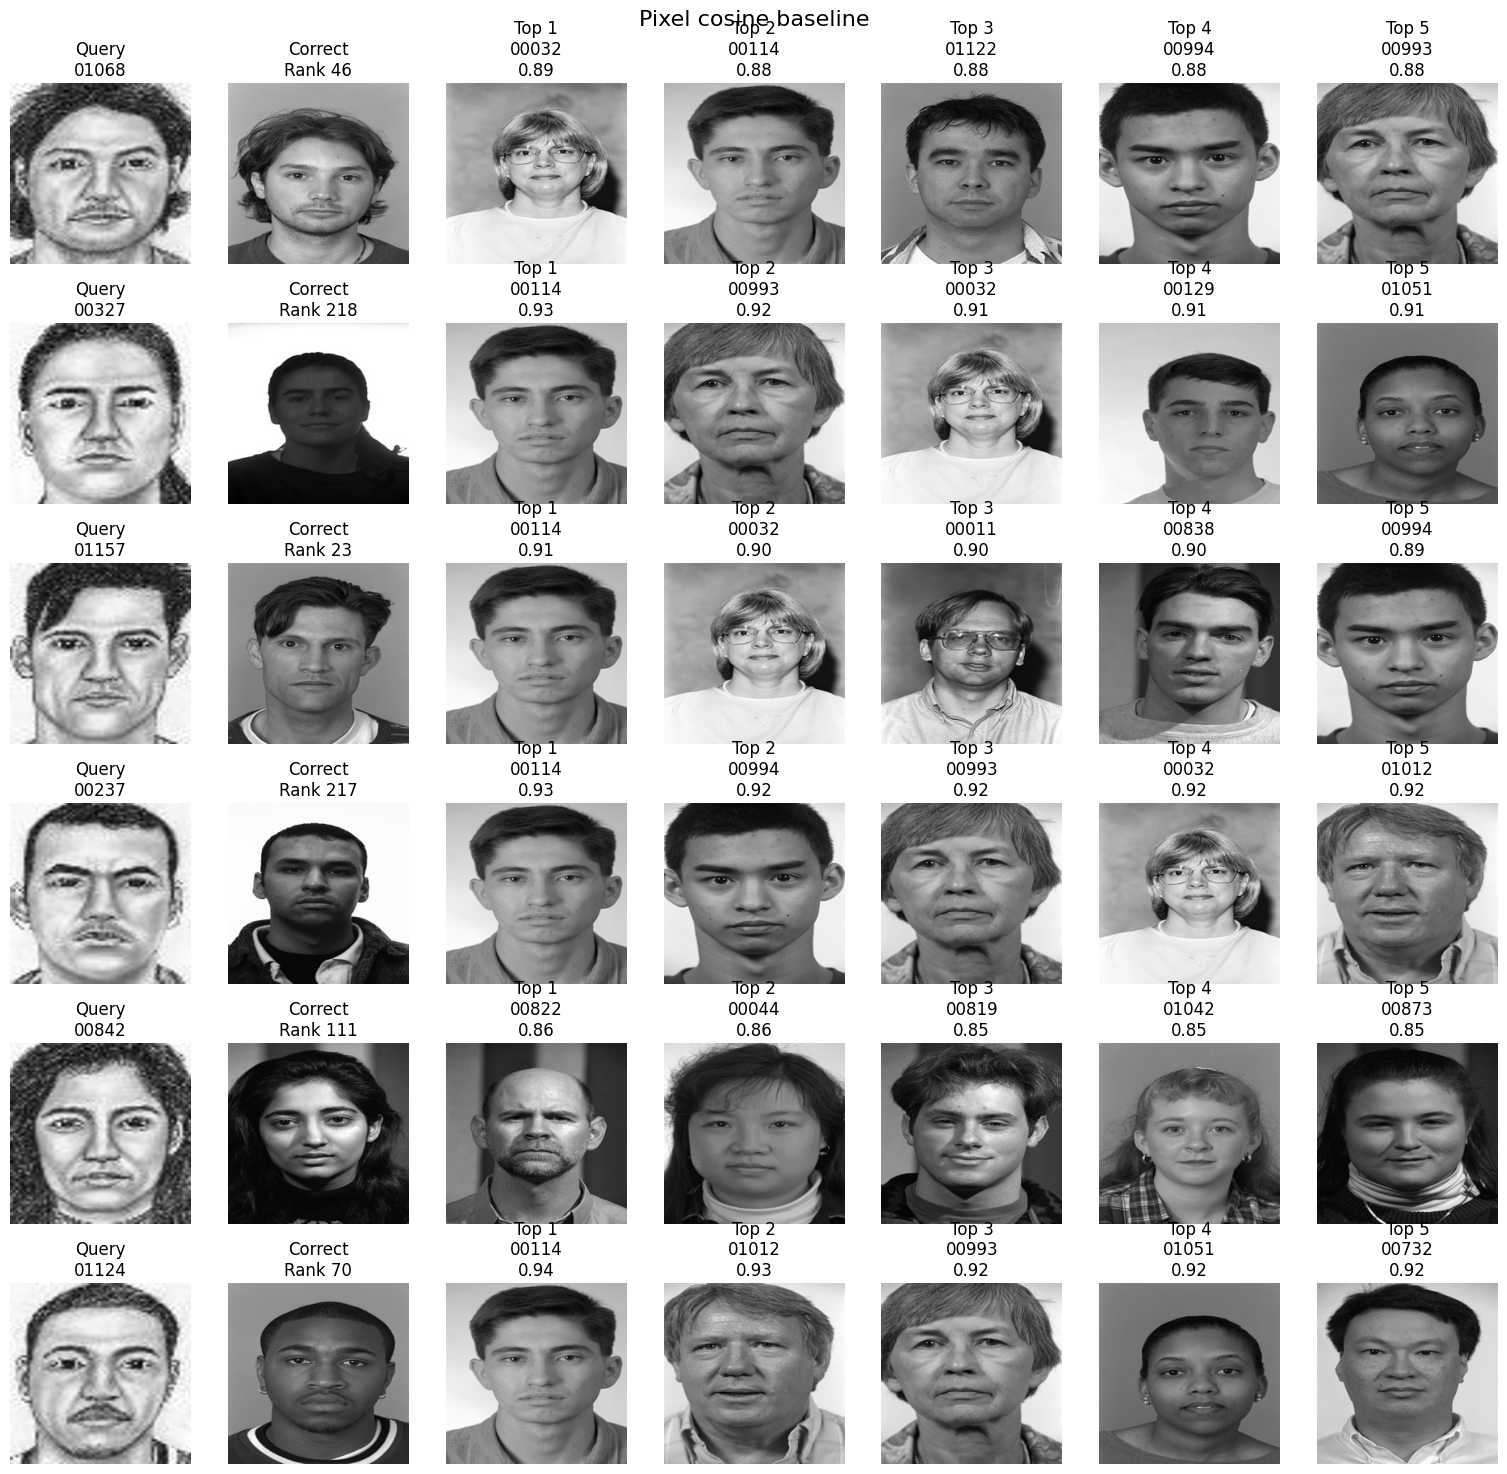

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/baseline_cufsf/retrieval_examples/resnet18_top5_examples.png


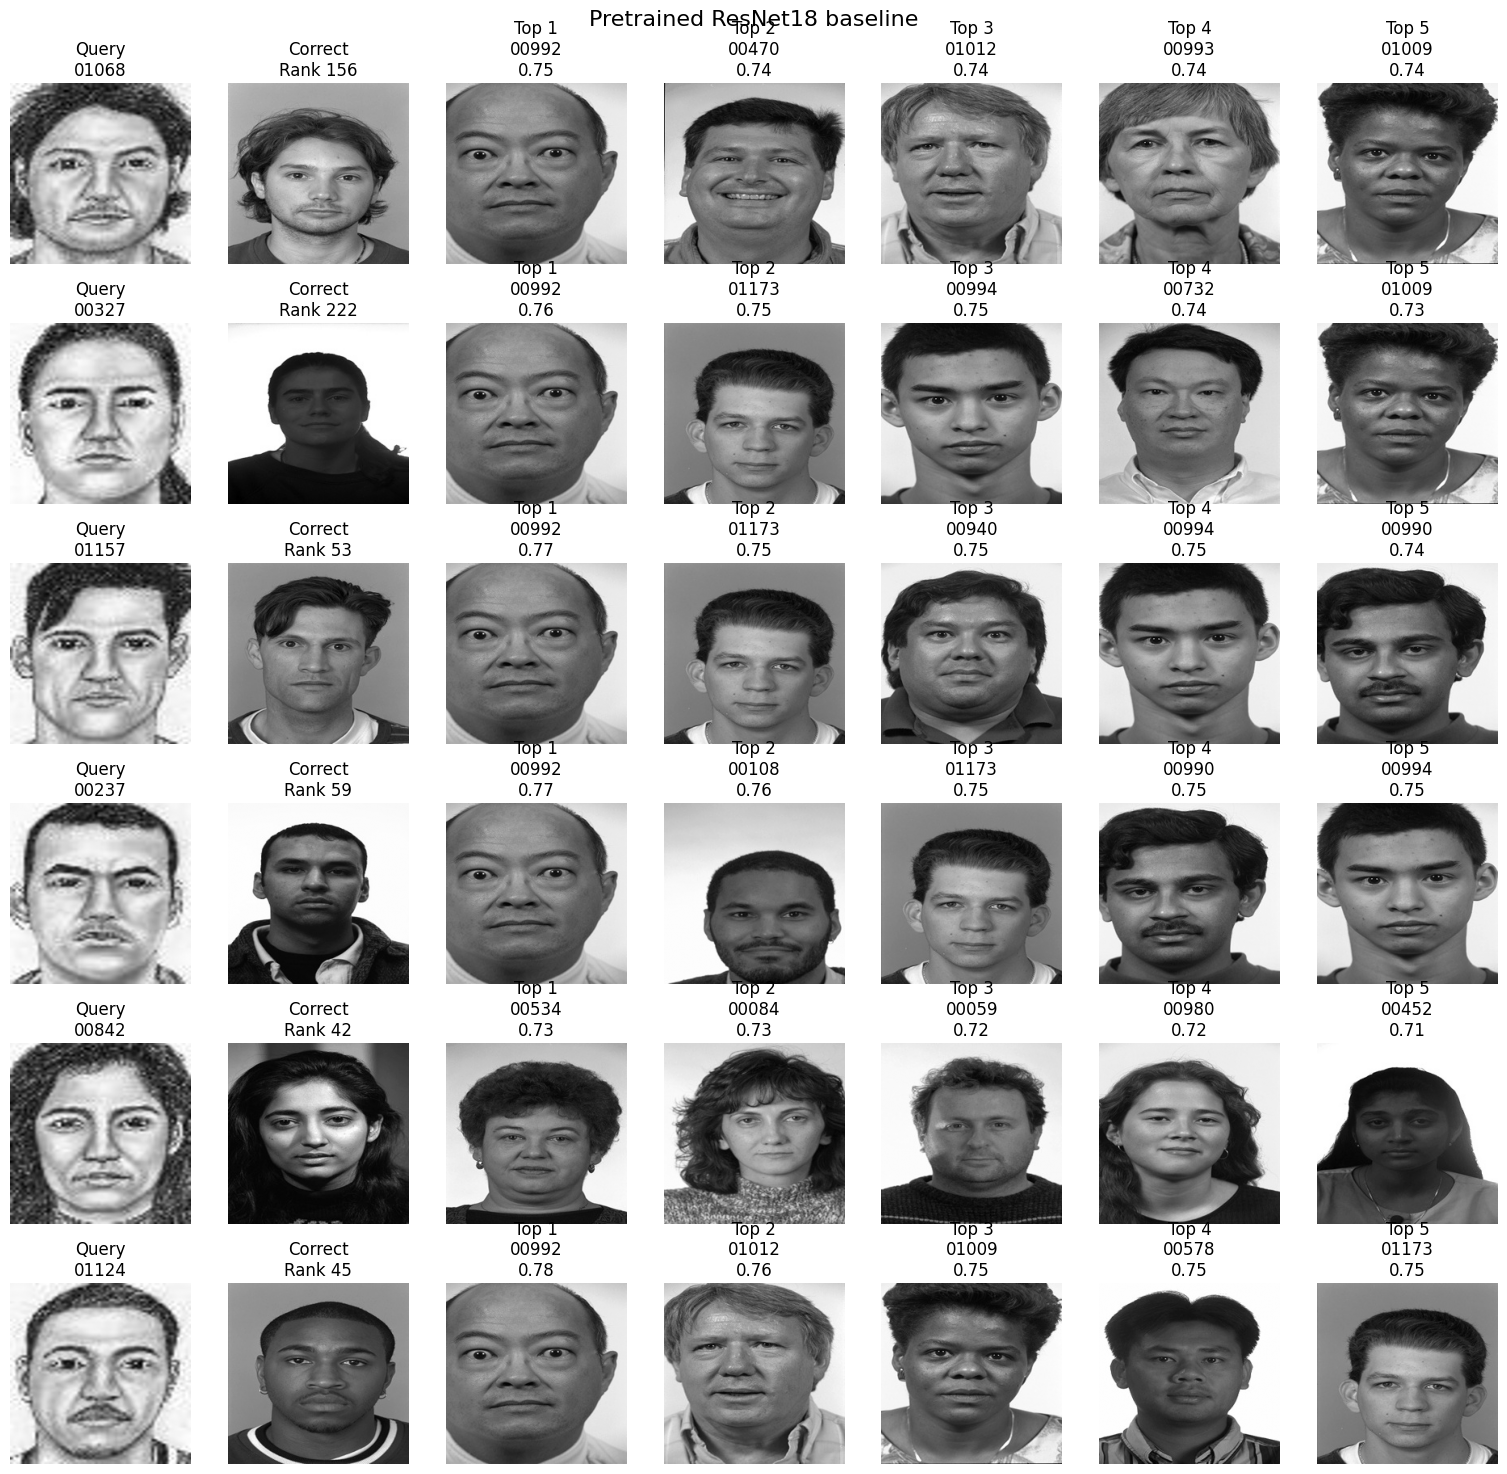

In [10]:
def make_retrieval_grid(df, similarity, ranks, method_name, n_examples=8, top_k=5, seed=42, save_path=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=min(n_examples, len(df)), replace=False)

    num_cols = 2 + top_k
    fig, axes = plt.subplots(len(indices), num_cols, figsize=(2.2 * num_cols, 2.5 * len(indices)))

    if len(indices) == 1:
        axes = np.array([axes])

    for row_i, query_idx in enumerate(indices):
        query = df.iloc[query_idx]
        ranked = np.argsort(-similarity[query_idx])[:top_k]

        sketch = Image.open(query["sketch_path"]).convert("L")
        correct = Image.open(query["photo_path"]).convert("L")

        axes[row_i, 0].imshow(sketch, cmap="gray")
        axes[row_i, 0].set_title(f"Query\n{query['id']}")
        axes[row_i, 0].axis("off")

        axes[row_i, 1].imshow(correct, cmap="gray")
        axes[row_i, 1].set_title(f"Correct\nRank {ranks[query_idx]}")
        axes[row_i, 1].axis("off")

        for j, gallery_idx in enumerate(ranked):
            item = df.iloc[gallery_idx]
            img = Image.open(item["photo_path"]).convert("L")
            is_correct = item["id"] == query["id"]
            score = similarity[query_idx, gallery_idx]

            axes[row_i, 2 + j].imshow(img, cmap="gray")
            title = f"Top {j+1}\n{item['id']}\n{score:.2f}"
            if is_correct:
                title += "\n✓"
            axes[row_i, 2 + j].set_title(title)
            axes[row_i, 2 + j].axis("off")

    fig.suptitle(method_name, fontsize=16)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


make_retrieval_grid(
    test_df,
    random_similarity,
    random_ranks,
    method_name="Random retrieval baseline",
    n_examples=6,
    top_k=5,
    seed=SEED,
    save_path=RETRIEVAL_DIR / "random_top5_examples.png",
)

make_retrieval_grid(
    test_df,
    pixel_similarity,
    pixel_ranks,
    method_name="Pixel cosine baseline",
    n_examples=6,
    top_k=5,
    seed=SEED,
    save_path=RETRIEVAL_DIR / "pixel_top5_examples.png",
)

make_retrieval_grid(
    test_df,
    resnet_similarity,
    resnet_ranks,
    method_name="Pretrained ResNet18 baseline",
    n_examples=6,
    top_k=5,
    seed=SEED,
    save_path=RETRIEVAL_DIR / "resnet18_top5_examples.png",
)

## 11. Rank distribution

This shows whether the correct photo is generally near the top or buried deep in the gallery.

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/baseline_cufsf/rank_distribution.png


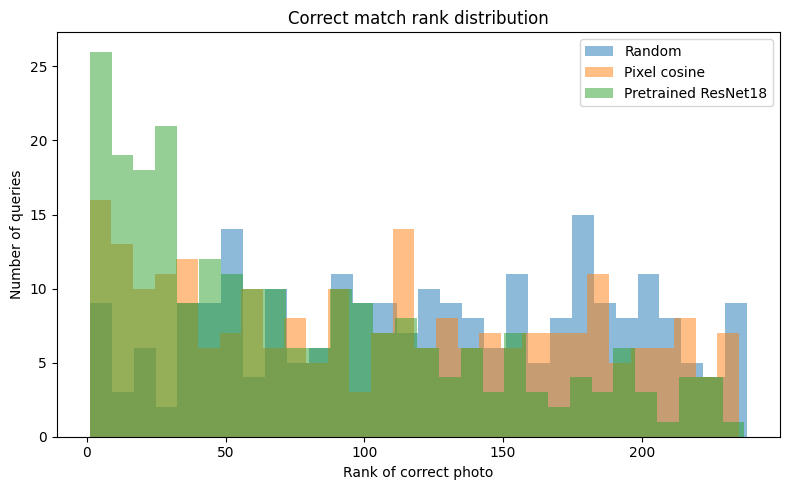

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(random_ranks, bins=30, alpha=0.5, label="Random")
plt.hist(pixel_ranks, bins=30, alpha=0.5, label="Pixel cosine")
plt.hist(resnet_ranks, bins=30, alpha=0.5, label="Pretrained ResNet18")
plt.xlabel("Rank of correct photo")
plt.ylabel("Number of queries")
plt.title("Correct match rank distribution")
plt.legend()
plt.tight_layout()

rank_plot_path = OUTPUT_DIR / "rank_distribution.png"
plt.savefig(rank_plot_path, dpi=150, bbox_inches="tight")
print("Saved:", rank_plot_path)
plt.show()